### Exploratory Data Analysis (EDA)
The goal of this notebook is to 

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import numpy as np

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)


Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


Variables with more than 50% missing values were identified and excluded from further analysis prior to modeling. The table below shows these variables and their percentage of missingness.
Tjc28, and scj28 are excluded also because they are highly correlated to DAS28, that has less missingness.

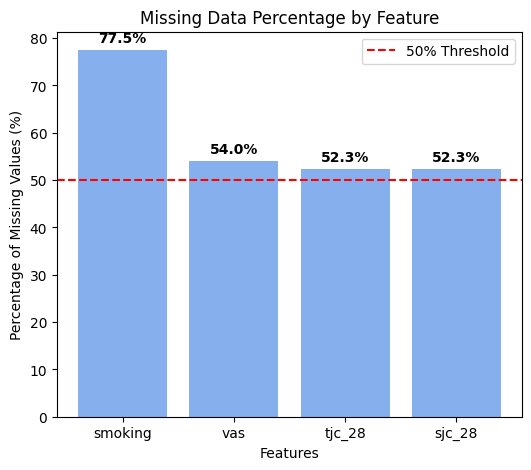

In [23]:
from src.preprocessing import handle_categorical_missing, load_data

df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
high_missing = missing_percent[missing_percent > 50]

plt.figure(figsize=(6, 5))
graph = plt.bar(high_missing.index.to_numpy(), high_missing.to_numpy(), color="#85b0ed")

for p in graph:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    plt.text(
        x,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        weight="bold"
    )
plt.axhline(50, color='red', linestyle='--', label='50% Threshold')
plt.title('Missing Data Percentage by Feature')
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values (%)')
plt.legend()
plt.show()

#### Dataset Overview

In [24]:
df_cleaned.shape

(228, 46)

In [25]:
df_cleaned.head(10)

,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,NaN,NaN,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,1,1,0,2
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,1,1,0,2
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,1,1,0,2
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,1,0,0,0,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,1,1,0,1,3
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,1,1,0,1,2


In [26]:
df_cleaned.columns.to_list()

['patient_id',
 'gender',
 'year_of_diagnosis',
 'rf_status',
 'anti_ccp_status',
 'comorbidities',
 'visit_date',
 'visit_type',
 'crp',
 'crp_upper_limit',
 'esr',
 'das28_score',
 'csdmard_name',
 'mtx_use',
 'mtx_dose',
 'b_ts_dmard_name',
 'steroid_dose',
 'treatment_decision',
 'switch_reason',
 'flare_event',
 'source',
 'birth_year',
 'days_since_last_visit',
 'disease_duration',
 'age_at_visit',
 'das28_change',
 'previous_flare',
 'target_flare_next',
 'crp_missing',
 'esr_missing',
 'crp_normalized',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_renal_urological',
 'comorb_gastrointestinal_hepatic',
 'comorb_malignancy',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'steroid_use',
 'treatment_count']

In [ ]:
cols_to_drop = ['year_of_diagnosis', 'crp', 'crp_upper_limit', 'source']
df_eda = df_cleaned.drop(columns=cols_to_drop)
df_eda.head()


0      0.00
1      0.74
2     -1.15
4      0.00
5     -1.25
       ... 
292     NaN
293     NaN
294   -0.76
295    2.57
296    0.46
Name: das28_change, Length: 228, dtype: float64

In [ ]:
df_eda.describe().T

In [29]:
df_eda.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 228 entries, 0 to 296
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       228 non-null    str           
 1   gender                           228 non-null    Int64         
 2   rf_status                        225 non-null    Int64         
 3   anti_ccp_status                  225 non-null    Int64         
 4   comorbidities                    228 non-null    str           
 5   visit_date                       228 non-null    datetime64[us]
 6   visit_type                       228 non-null    str           
 7   esr                              192 non-null    float64       
 8   das28_score                      134 non-null    float64       
 9   csdmard_name                     228 non-null    str           
 10  mtx_use                          228 non-null    Int64         
 11  mtx_dose 

#### Missingness

In [30]:
missing_count = df_eda.isnull().sum()
missing_percentage = (df_eda.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]

,missing_count,missing_percentage
das28_change,95,41.7
das28_score,94,41.2
crp_normalized,66,28.9
esr,36,15.8
rf_status,3,1.3
anti_ccp_status,3,1.3
disease_duration,2,0.9


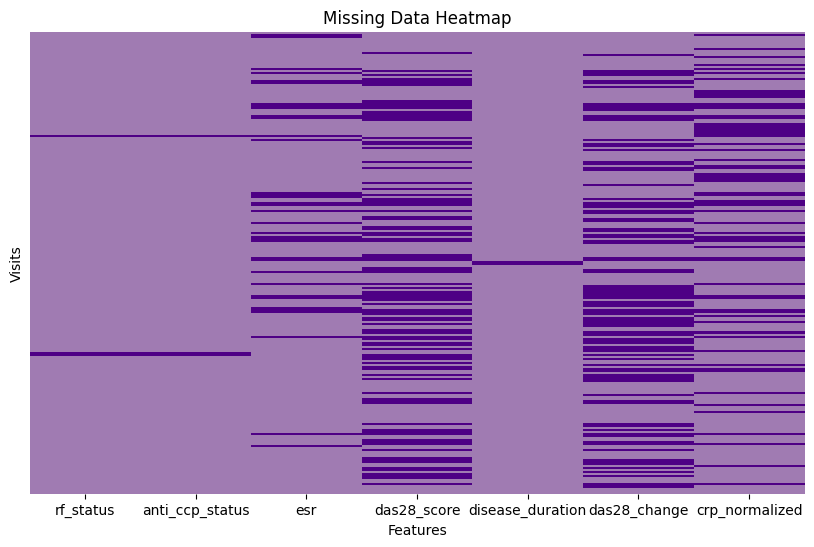

In [31]:
#Missingness Visualization
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#A07BB2FF", "#4e0085"])


#Heatmap of missing values
missing_cols = df_eda.columns[df_eda.isnull().any()]
plt.figure(figsize=(10, 6))
sns.heatmap(df_eda[missing_cols].isnull(), cbar=False, cmap=cmap, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Features')
plt.ylabel('Visits')
plt.show()


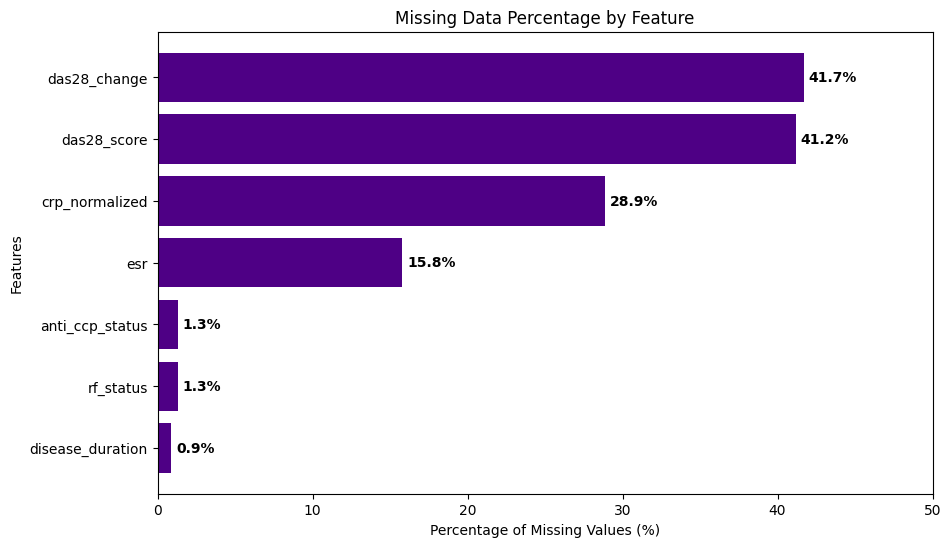

In [32]:
#Barplot of missing values
missing_plot = (missing_table[missing_table['missing_percentage'] > 0]
                .sort_values(by='missing_percentage', ascending=True))

plt.figure(figsize=(10, 6))
graph = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color='#4e0085')

for p in graph:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.text(
        width + 0.3,   
        y,
        f"{width:.1f}%",
        va="center",
        weight="bold"
    )

plt.title('Missing Data Percentage by Feature')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.xlim(0, 50)
plt.show()


In [33]:
crp_counts = pd.crosstab(df_eda['crp_missing'], df_eda['target_flare_next'], 
            rownames=['CRP missing'], colnames=['Flare next visit'])


crp_percent = pd.crosstab(df_eda["crp_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)

display(crp_counts)
display(crp_percent)

Flare next visit,0,1
CRP missing,,
0,96,66
1,42,24


Flare next visit,0,1
CRP missing,,
0,0.59,0.41
1,0.64,0.36


In [34]:
esr_counts = pd.crosstab(df_eda['esr_missing'], df_eda['target_flare_next'], 
            rownames=['ESR missing'], colnames=['Flare next visit'])


esr_percent = pd.crosstab(df_eda["esr_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)

display(esr_counts)
display(esr_percent)

Flare next visit,0,1
ESR missing,,
0,112,80
1,26,10


Flare next visit,0,1
ESR missing,,
0,0.58,0.42
1,0.72,0.28


In [35]:
df_eda['das28_missing'] = df_eda['das28_change'].isnull().astype(int)

das28_counts = pd.crosstab(df_eda['das28_missing'], df_eda['target_flare_next'], 
            rownames=['DAS28 Missing'], colnames=['Flare next visit'])


das28_percent = pd.crosstab(df_eda["das28_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)

display(das28_counts)
display(das28_percent)

Flare next visit,0,1
DAS28 Missing,,
0,78,55
1,60,35


Flare next visit,0,1
DAS28 Missing,,
0,0.59,0.41
1,0.63,0.37


### Does feature missingness appear to affect the target variable?

<span style="color: green;">**CRP**</span>  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When CRP is present (0) : 41%  
- When CRP is not present (1): 36%  
- Difference: 5%. 


This small difference suggests that CRP missingness is not strongly associated with the outcome and is unlikely to represent highly informative missingness.



<span style="color: cyan;">**ESR**</span>   
For ESR, visits with missing values showed a lower proportion of next-visit flare compared with visits where ESR was available.  
- When ESR is present (0) and available 80/192: 42%  
- When ESR is not present (1) and missing 10/36: 28%  
- Difference: 14%  

This more noticeable difference suggests that ESR missingness may carry some information and may not be completely random, although the number of visits with missing ESR was smaller.
  
<span style="color: purple;">**DAS28 score**</span>   
Because DAS28_score and DAS28_change are highly correlated, only das28_score missingness percentage was evaluated.  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When DAS28 is present (0), and available 55/133: 41%  
- When DAS28 is not present (1) and available 35/95: 37%  
- Difference: 4%   

This small difference suggests that DAS28 score missingness is not strongly associated with the outcome.

### Target Analysis


In [36]:
# Percentages of target variable
df_eda["target_flare_next"].value_counts(normalize=True, dropna=False) * 100

target_flare_next
0    60.526316
1    39.473684
Name: proportion, dtype: float64

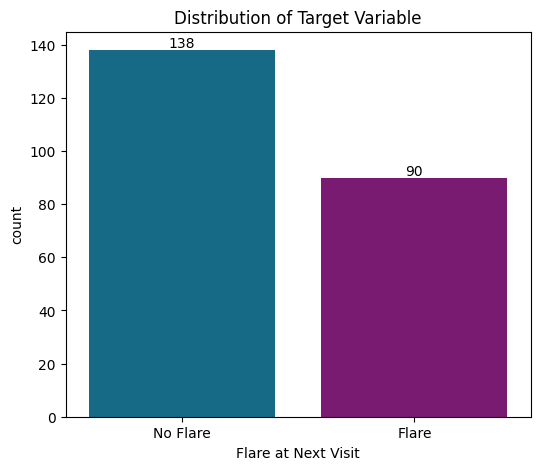

In [37]:
# Counts of target variable
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='target_flare_next', data=df_eda, 
                      hue= 'target_flare_next', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Flare at Next Visit')
plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])


for p in graph.patches: 
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

The target variable 'flare_next_visit' showed a small imbalance between Flare and no Flare events.

### Visits per patient

In [38]:
#visits per patient
visits_per_patient = df_eda.groupby('patient_id').size()

#average visits per patient
visits_per_patient.describe()

count    70.000000
mean      3.257143
std       2.204644
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max      13.000000
dtype: float64

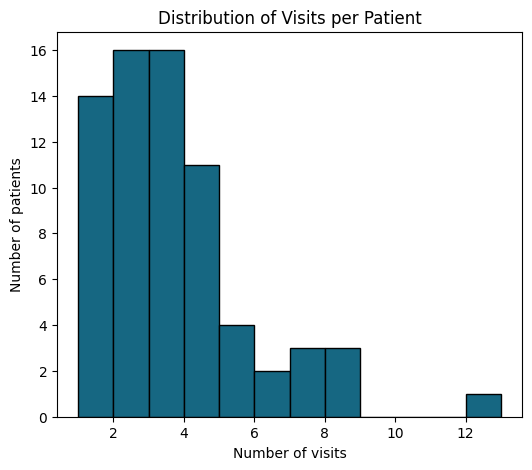

In [39]:
plt.figure(figsize=(6, 5))
graph = plt.hist(visits_per_patient, bins=12, color = "#166782FF", edgecolor='black')
plt.title('Distribution of Visits per Patient')
plt.xlabel('Number of visits')
plt.ylabel('Number of patients')
plt.show()

The number of visits per patient was examined to better characterize the longitudinal structure of the dataset. A total of **70 patients** were included, with a mean of **3.26 visits per patient** (SD = **2.20**) and a median of **3 visits**. Most patients contributed between **2 and 4 visits**, although follow-up was unequal across the cohort, ranging from **1 to 13 visits**. This pattern is consistent with real-world longitudinal clinical data, where the number of recorded visits varies between patients.

### Univariate Analysis

Continuous variables


In [40]:
df_eda['das28_score'].describe()

count    134.000000
mean       3.713657
std        1.273935
min        1.050000
25%        2.845000
50%        3.595000
75%        4.722500
max        6.800000
Name: das28_score, dtype: float64

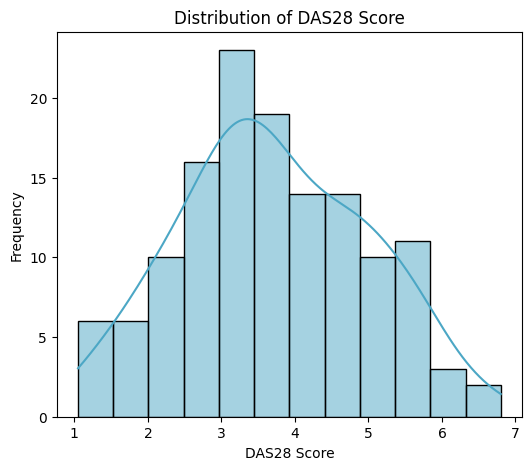

In [41]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_eda.dropna(subset=['das28_score']),
    x='das28_score',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of DAS28 Score')
plt.xlabel('DAS28 Score')
plt.ylabel('Frequency')
plt.show()

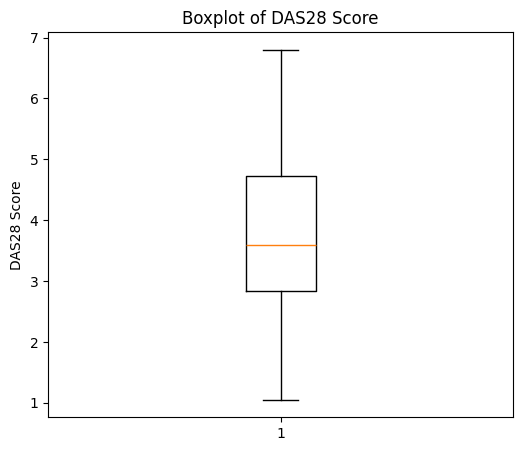

In [42]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_eda['das28_score'].dropna(), vert=True)
plt.title('Boxplot of DAS28 Score')
plt.ylabel('DAS28 Score')
plt.show()

In [43]:
df_eda['crp_normalized'].describe()

count    162.000000
mean       1.528625
std        3.319443
min        0.020000
25%        0.250000
50%        0.560000
75%        1.500000
max       32.000000
Name: crp_normalized, dtype: float64

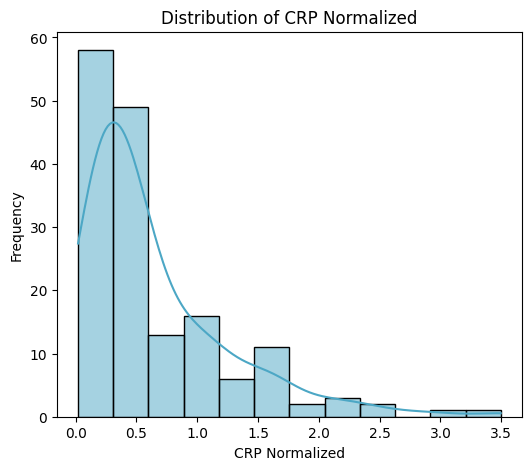

In [65]:
df_eda['log_crp_normalized'] = np.log1p(df_eda['crp_normalized'])
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_eda.dropna(subset=['log_crp_normalized']),
    x='log_crp_normalized',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of CRP Normalized')
plt.xlabel('CRP Normalized')
plt.ylabel('Frequency')
plt.show()

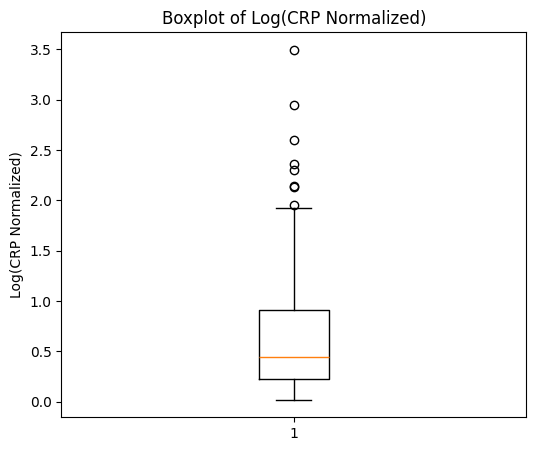

In [66]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_eda['log_crp_normalized'].dropna(), vert=True)
plt.title('Boxplot of Log(CRP Normalized)')
plt.ylabel('Log(CRP Normalized)')
plt.show()

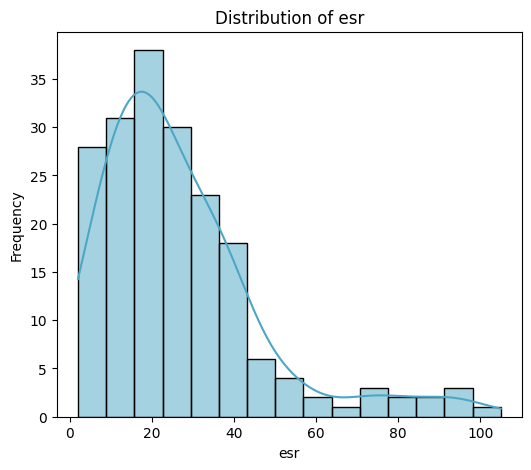

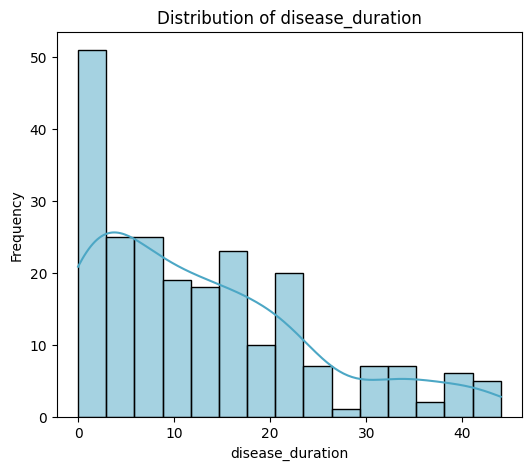

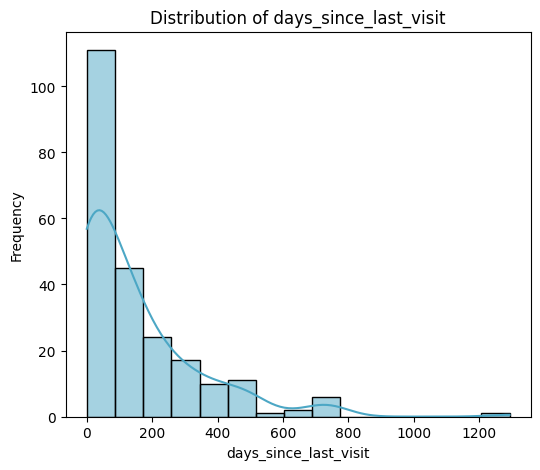

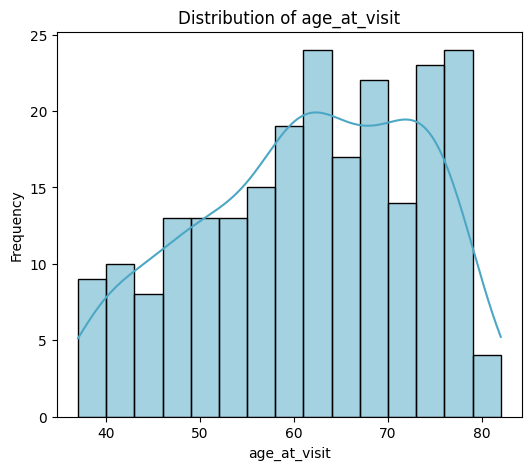

In [46]:
continuous_variables = [
                'esr',
                'disease_duration',
                'days_since_last_visit', 
                'age_at_visit'
]

for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    sns.histplot(
        data=df_eda.dropna(subset=[col]),
        x=col,
        bins=15,
        color="#4CA7C5FF",
        kde=True,
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

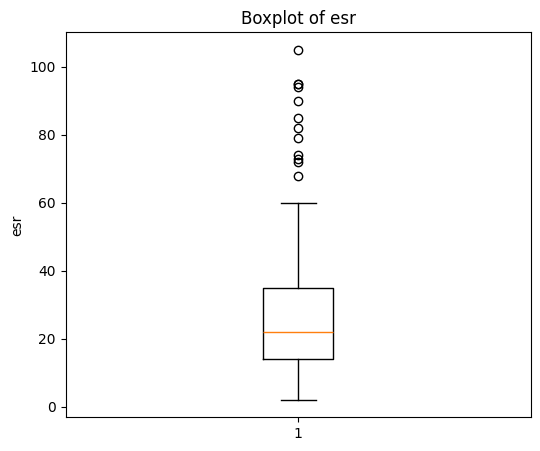

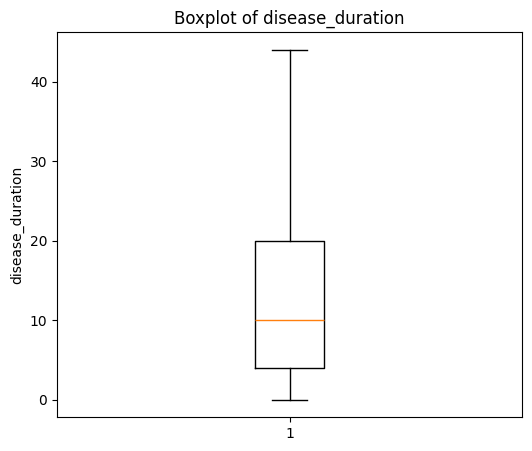

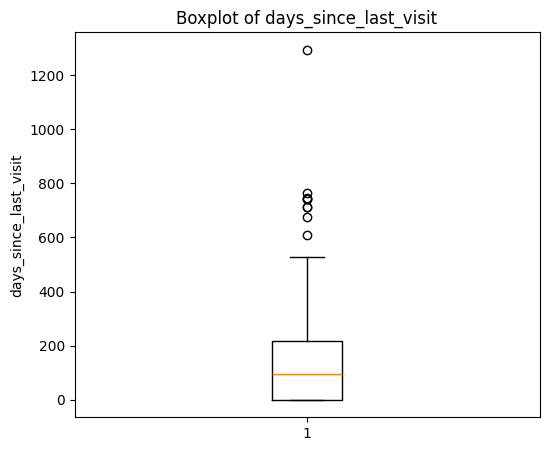

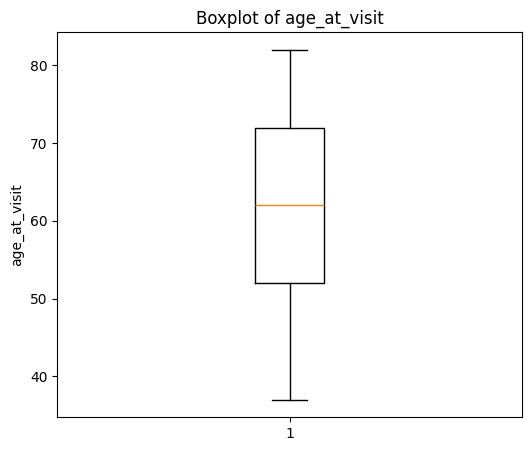

In [47]:
for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    plt.boxplot(x=df_eda[col].dropna(), vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [48]:
df_eda['mtx_dose'].value_counts().sort_index()

mtx_dose
0.0     108
5.0       2
7.5       4
10.0     22
12.0      1
12.5      2
15.0     44
17.5      3
20.0     32
25.0     10
Name: count, dtype: int64

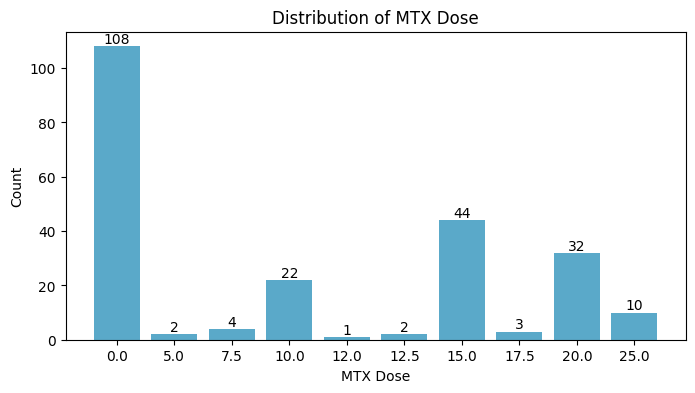

In [49]:
dose_counts = df_eda["mtx_dose"].value_counts().sort_index()
x_labels = dose_counts.index.astype(str).to_list()
y_counts = dose_counts.to_numpy(dtype=float)

plt.figure(figsize=(8,4))
bars = plt.bar(x_labels, y_counts, color="#5aa9c9")
plt.title("Distribution of MTX Dose")
plt.xlabel("MTX Dose")
plt.ylabel("Count")

for b in bars: 
    height = b.get_height()
    plt.text(
        b.get_x() + b.get_width()/2,
        height +1,
        f'{int(height)}', 
        ha = 'center'
    )

plt.show()

In [50]:
df_eda['steroid_dose'].value_counts().sort_index()

steroid_dose
0.0     133
2.0       4
2.5      11
4.0      20
5.0      24
6.0      15
7.5      10
8.0       2
10.0      6
15.0      1
20.0      2
Name: count, dtype: int64

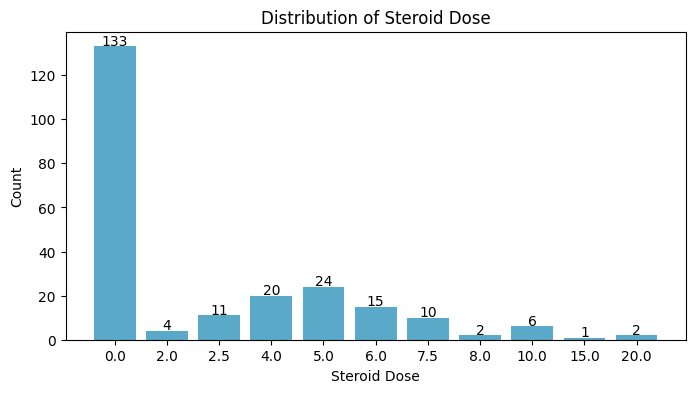

In [51]:
dose_counts = df_eda["steroid_dose"].value_counts().sort_index()

x_labels = dose_counts.index.astype(str).tolist()
y_counts = dose_counts.to_numpy(dtype=float)

plt.figure(figsize=(8, 4))
bars = plt.bar(x_labels, y_counts, color="#5aa9c9")

plt.title("Distribution of Steroid Dose")
plt.xlabel("Steroid Dose")
plt.ylabel("Count")

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2,
    h + 0.5,
    f"{int(h)}",
    ha="center")

plt.show()

Categorical variables

In [52]:
df_eda['gender'].value_counts()

gender
1    183
0     45
Name: count, dtype: Int64

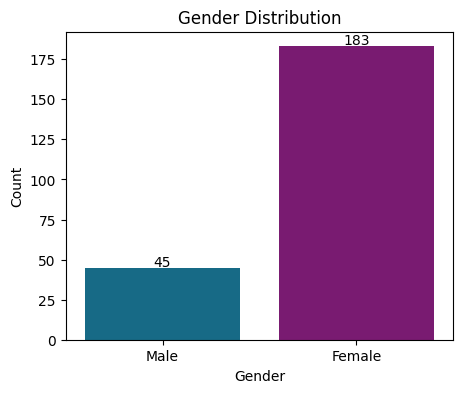

In [53]:
plt.figure(figsize=(5, 4))
graph = sns.countplot(x='gender', data=df_eda, hue = 'gender', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels= ['Male', 'Female'] )

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
    
plt.show()

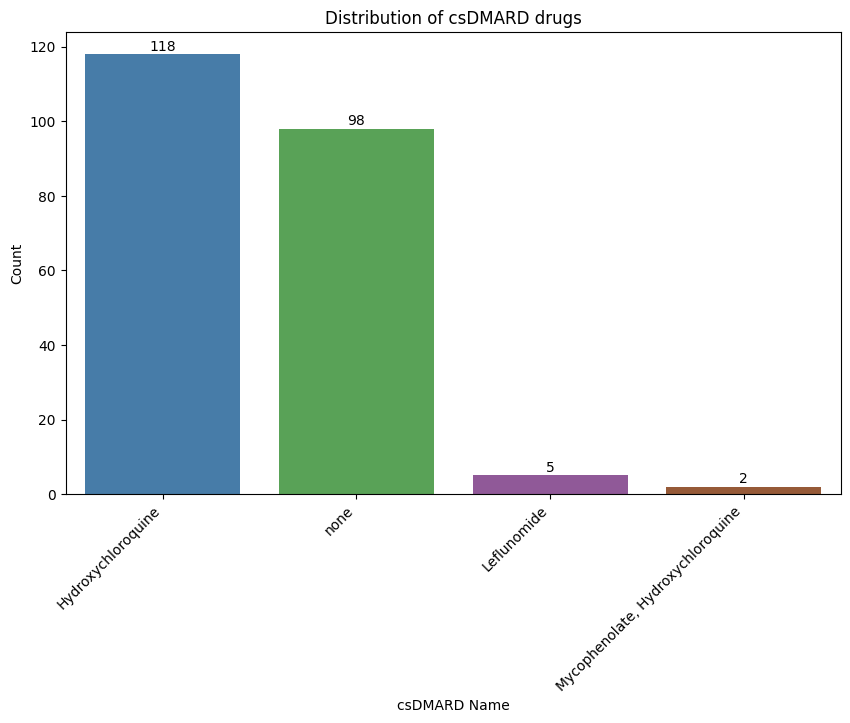

In [54]:
drug_order = df_eda["csdmard_name"].value_counts(dropna=False).head(4).index
plt.figure(figsize=(10, 6))
graph = sns.countplot(x='csdmard_name', data=df_eda, order= drug_order, hue='csdmard_name', palette= sns.color_palette("Set1"), legend=False)
plt.title('Distribution of csDMARD drugs')
plt.xlabel('csDMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

C:\Users\konna\AppData\Local\Temp\ipykernel_36508\2526925158.py:4: UserWarning: 
The palette list has fewer values (8) than needed (9) and will cycle, which may produce an uninterpretable plot.
  graph = sns.countplot(x='b_ts_dmard_name', data=df_eda, order= drug_order, hue='b_ts_dmard_name', palette= sns.color_palette("Set2"), legend=False)


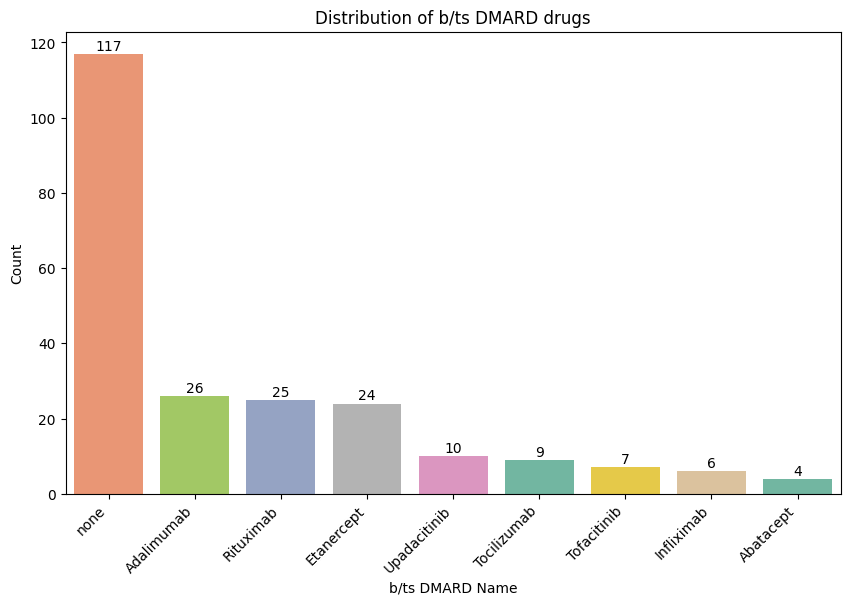

In [55]:
drug_order = df_eda["b_ts_dmard_name"].value_counts(dropna=False).index

plt.figure(figsize=(10, 6))
graph = sns.countplot(x='b_ts_dmard_name', data=df_eda, order= drug_order, hue='b_ts_dmard_name', palette= sns.color_palette("Set2"), legend=False)
plt.title('Distribution of b/ts DMARD drugs')
plt.xlabel('b/ts DMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

In [56]:
comorb_cols = [
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'
]

comorb_label_map = {
    "comorb_cardiovascular": "Cardiovascular",
    "comorb_metabolic_endocrine": "Metabolic / Endocrine",
    "comorb_respiratory": "Respiratory",
    "comorb_renal_urological": "Renal / Urological",
    "comorb_gastrointestinal_hepatic": "Gastrointestinal / Hepatic",
    "comorb_malignancy": "Malignancy",
    "comorb_musculoskeletal": "Musculoskeletal",
    "comorb_neurologic_psychiatric": "Neurologic / Psychiatric",
    "comorb_autoimmune_other": "Autoimmune / Other"
}


patient_comorb = df_eda.groupby('patient_id')[comorb_cols].max()
comorb_counts = patient_comorb.sum().sort_values(ascending = False)
comorb_counts_named = comorb_counts.rename(index=comorb_label_map)


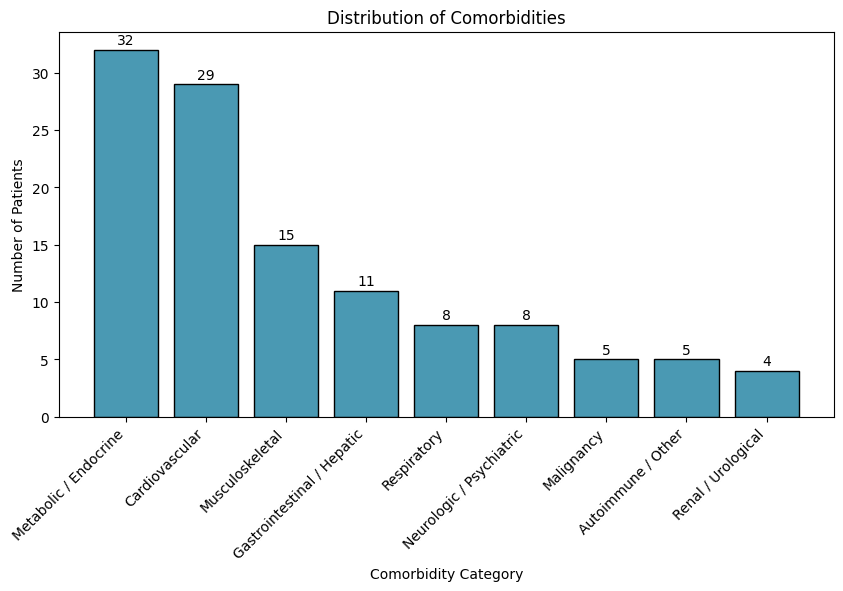

In [57]:
x_labels = comorb_counts_named.index.astype(str).to_list()
y_counts = comorb_counts_named.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
graph = plt.bar(
    x_labels,
    y_counts,
    color="#4A99B3FF",
    edgecolor="black"
)
plt.title("Distribution of Comorbidities")
plt.xlabel("Comorbidity Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha="right")

for p in graph: 
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width() / 2,
        height + 0.2,
        f"{int(height)}",
        ha='center', 
        va='bottom'      
    )
plt.show()

In [58]:
df_eda['treatment_decision'].value_counts(normalize=True, dropna=False) * 100


treatment_decision
no_decision    30.701754
stable         25.877193
escalation     23.684211
tapering       11.842105
switch          7.894737
Name: proportion, dtype: float64

In [59]:
df_eda['switch_reason'].value_counts(normalize=True, dropna=False) * 100

switch_reason
no_switch        92.982456
Inefficacy        6.578947
Adverse event     0.438596
Name: proportion, dtype: float64

### Bivariate Analysis
Continuous variables

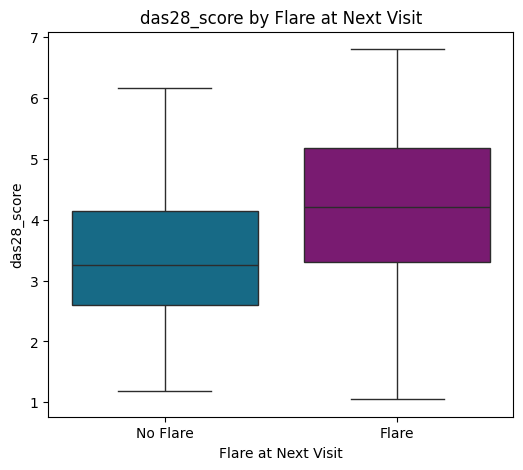

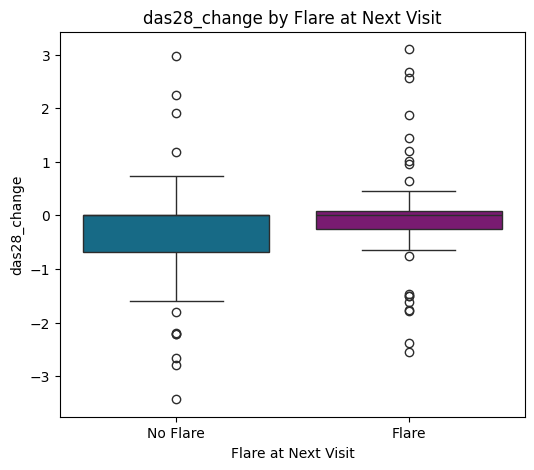

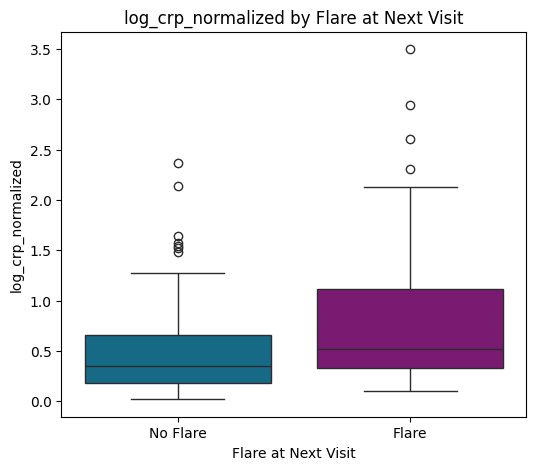

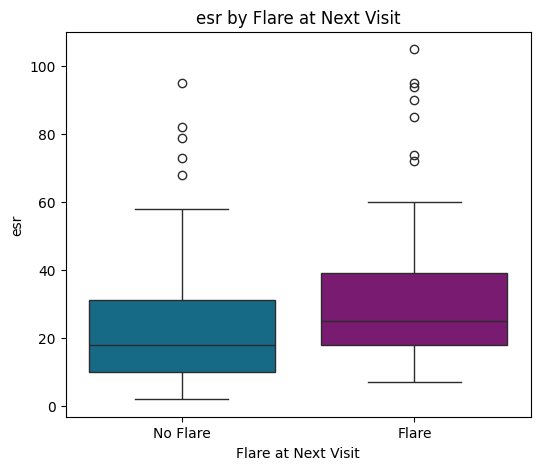

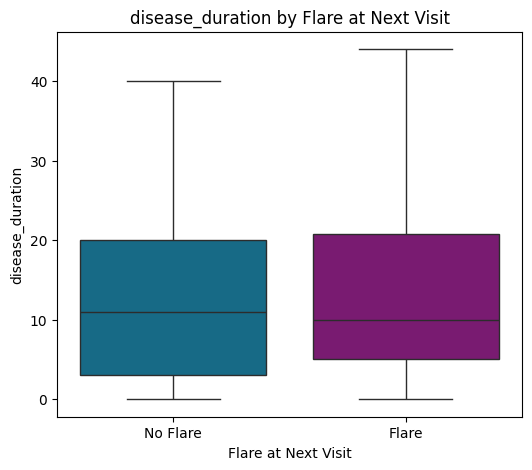

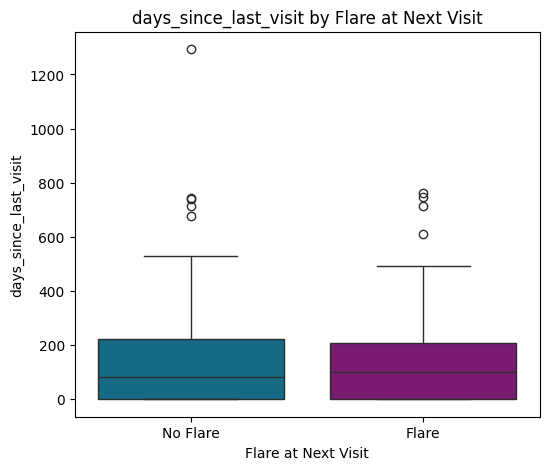

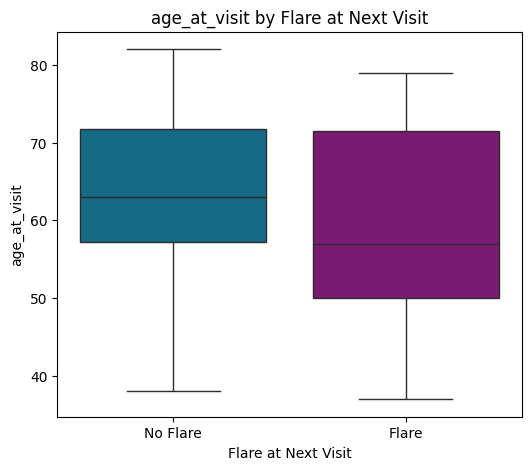

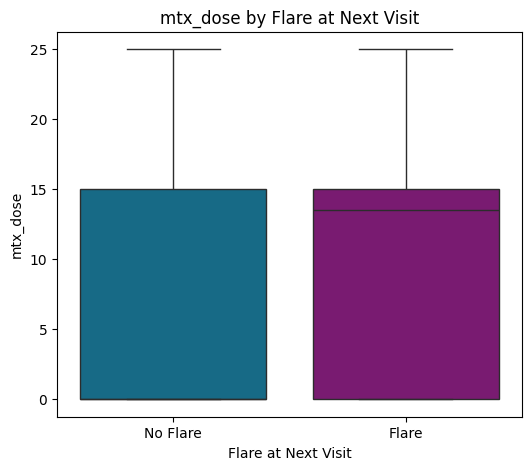

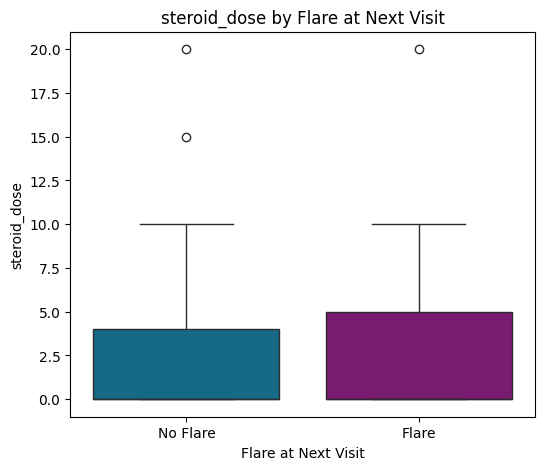

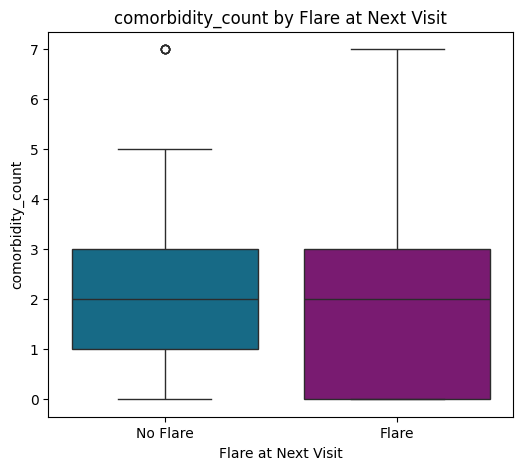

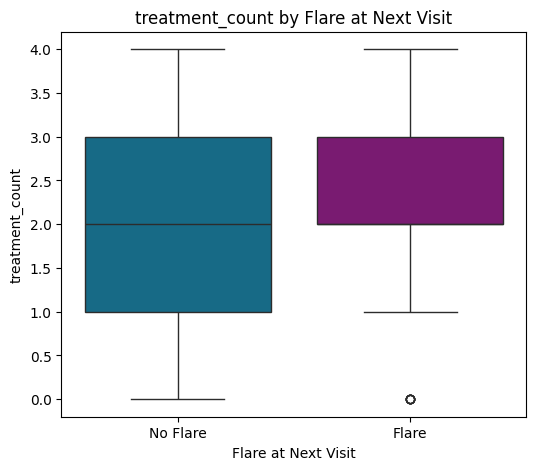

In [63]:
df_eda['log_crp_normalized'] = np.log1p(df_eda['crp_normalized'])

continuous_cols = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'esr', 
    'disease_duration', 'days_since_last_visit',
    'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count'
    ]

for col in continuous_cols:
    plt.figure(figsize=(6,5))
    sns.boxplot(
        data = df_eda, x='target_flare_next',
        y=col, hue='target_flare_next', 
        palette=["#047398", "#880c7e"], legend=False)
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel('Flare at Next Visit')
    plt.ylabel(col)
    plt.xticks(ticks=[0,1], labels=['No Flare', 'Flare'])
    plt.show()

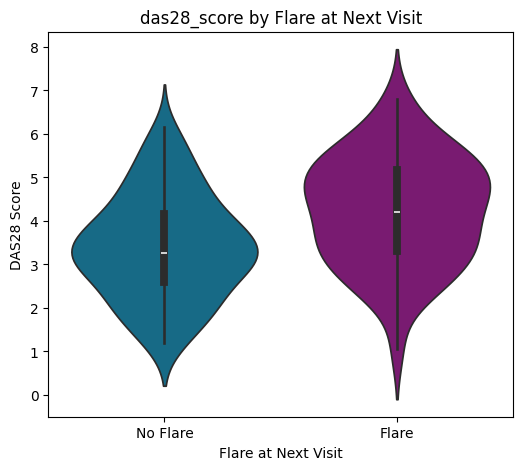

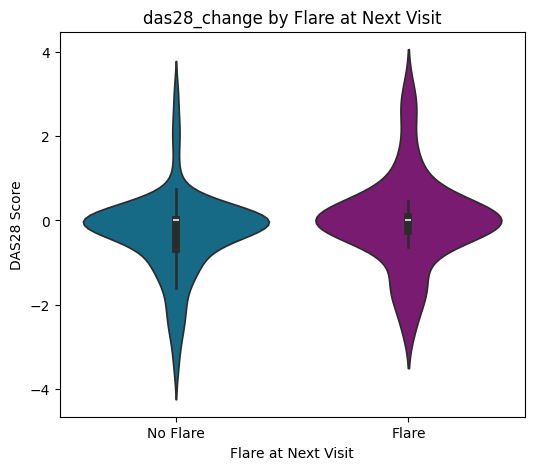

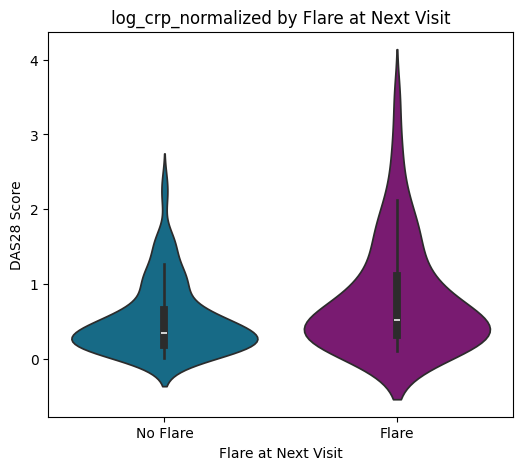

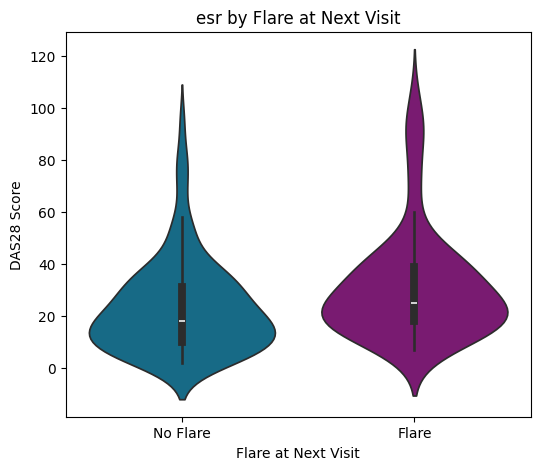

In [72]:
cont_cols = ['das28_score', 'das28_change', 'log_crp_normalized', 'esr',]

for col in cont_cols:
    plt.figure(figsize=(6, 5))
    sns.violinplot(data=df_eda, x="target_flare_next", y=col, hue='target_flare_next', palette=["#047398", "#880c7e"], legend=False)
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel('Flare at Next Visit')
    plt.ylabel('DAS28 Score')
    plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])
    plt.show()

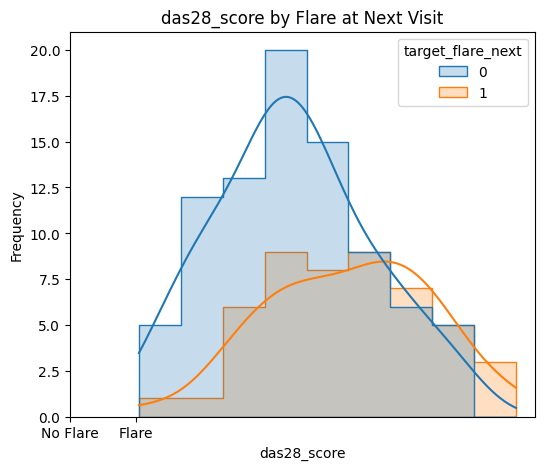

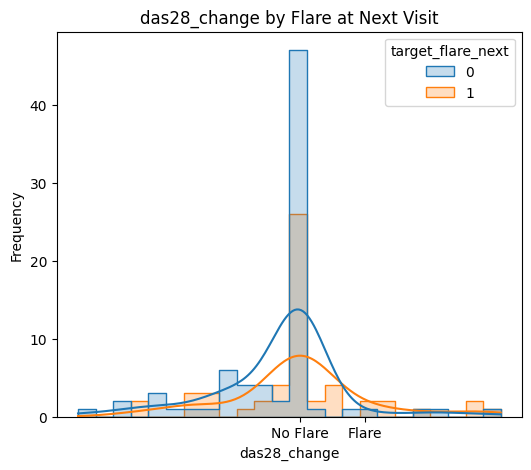

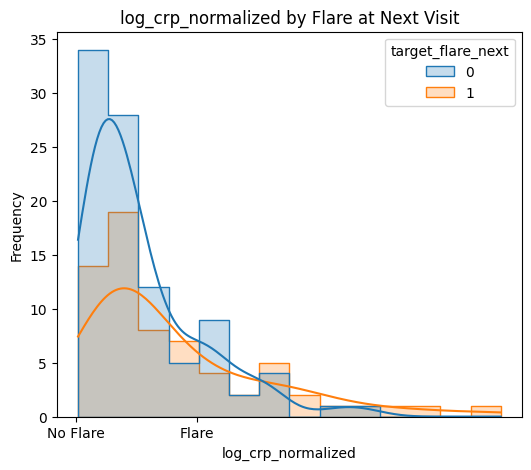

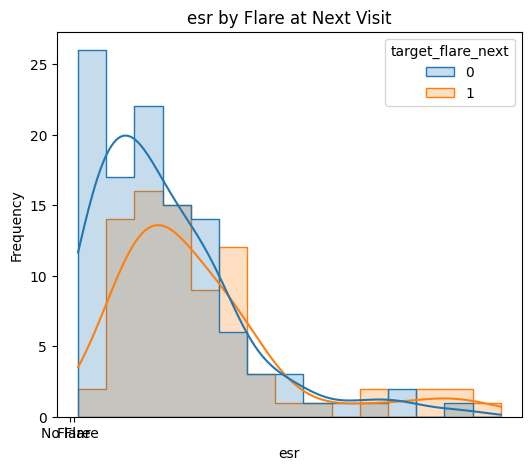

In [74]:

for col in cont_cols:
    plt.figure(figsize=(6, 5))
    sns.histplot(data=df_eda, x=col, hue="target_flare_next", kde=True, element="step")
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])
    plt.show()

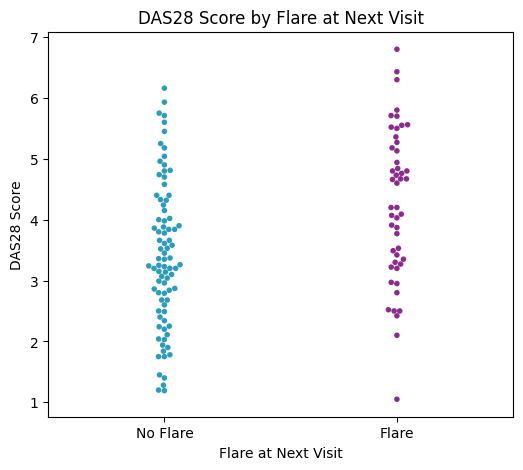

In [76]:
plt.figure(figsize=(6, 5))
sns.swarmplot(
    data=df_eda,
    x="target_flare_next",
    y="das28_score",
    hue="target_flare_next",
    palette=["#2A9DBF", "#8E2A8F"],
    legend=False,
    size=4
)
plt.title("DAS28 Score by Flare at Next Visit")
plt.xlabel("Flare at Next Visit")
plt.ylabel("DAS28 Score")
plt.xticks(ticks=[0, 1], labels=["No Flare", "Flare"])
plt.show()

Categorical variables



In [159]:
prev_flare = pd.crosstab(
    df_eda['previous_flare'],
    df_eda['target_flare_next'],
    rownames=['Previous Flare'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
prev_flare

Flare at Next Visit,0,1
Previous Flare,,
0,0.66,0.34
1,0.51,0.49


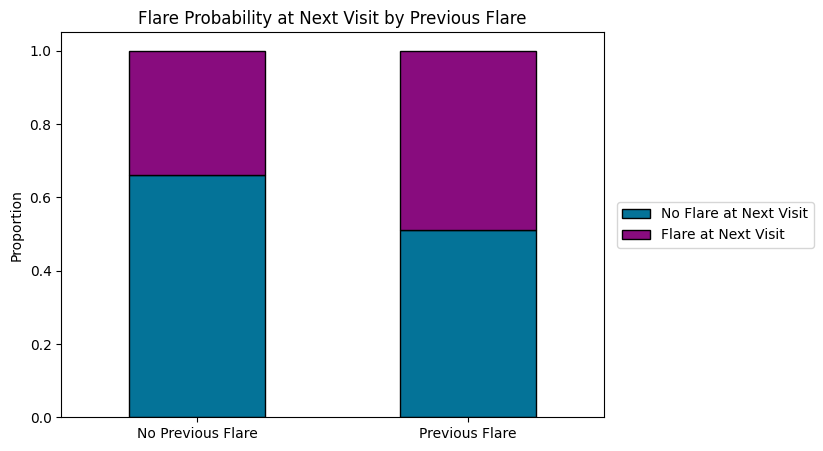

In [172]:
prev_flare.index = prev_flare.index = ["No Previous Flare", "Previous Flare"]
prev_flare.columns = ['No Flare at Next Visit', 'Flare at Next Visit']

prev_flare.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Previous Flare')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [116]:
pd.crosstab(
    df_eda['gender'],
    df_eda['target_flare_next'],
    rownames=['Gender'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Gender,,
0,0.53,0.47
1,0.62,0.38


In [117]:
pd.crosstab(
    df_eda['rf_status'],
    df_eda['target_flare_next'],
    rownames=['RF Status'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
RF Status,,
0,0.60,0.40
1,0.61,0.39


In [118]:
pd.crosstab(
    df_eda['anti_ccp_status'],
    df_eda['target_flare_next'],
    rownames=['Anti-CCP Status'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Anti-CCP Status,,
0,0.58,0.42
1,0.63,0.37


In [176]:
mtx_use = pd.crosstab(
    df_eda['mtx_use'],
    df_eda['target_flare_next'],
    rownames=['MTX Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
mtx_use

Flare at Next Visit,0,1
MTX Use,,
0,0.66,0.34
1,0.55,0.45


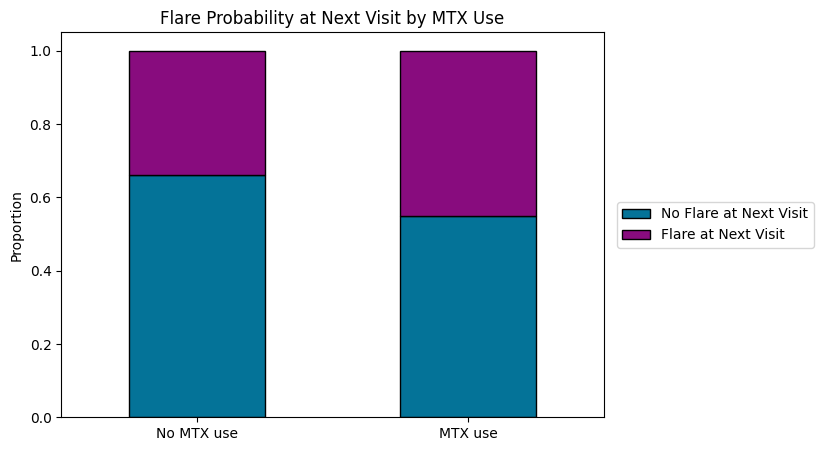

In [179]:
mtx_use.index = mtx_use.index = ["No MTX use", "MTX use"]
mtx_use.columns = ['No Flare at Next Visit', 'Flare at Next Visit']

mtx_use.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by MTX Use')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [120]:
df_eda['mtx_dose_bin'] = pd.cut(df_eda['mtx_dose'], bins=5)
pd.crosstab(
    df_eda['mtx_dose_bin'],
    df_eda['target_flare_next'],
    rownames=['MTX Dose'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
MTX Dose,,
"(-0.025, 5.0]",0.66,0.34
"(5.0, 10.0]",0.73,0.27
"(10.0, 15.0]",0.49,0.51
"(15.0, 20.0]",0.54,0.46
"(20.0, 25.0]",0.40,0.60


In [114]:
df_eda['mtx_dose_bin'].value_counts(dropna=False)

mtx_dose_bin
(-0.025, 5.0]    110
(10.0, 15.0]      47
(15.0, 20.0]      35
(5.0, 10.0]       26
(20.0, 25.0]      10
Name: count, dtype: int64

In [180]:
steroid_dose = pd.crosstab(
    df_eda['steroid_use'],
    df_eda['target_flare_next'],
    rownames=['Steroid Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
steroid_dose

Flare at Next Visit,0,1
Steroid Use,,
0,0.65,0.35
1,0.54,0.46


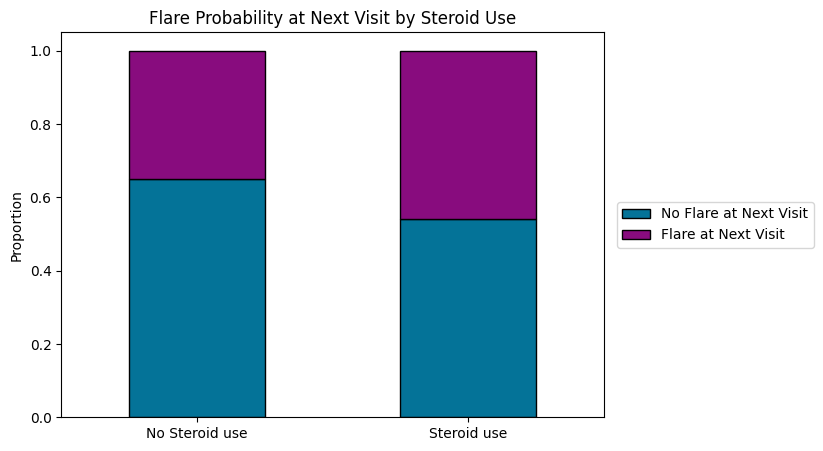

In [181]:
steroid_dose.index = steroid_dose.index = ["No Steroid use", "Steroid use"]
steroid_dose.columns = ['No Flare at Next Visit', 'Flare at Next Visit']
steroid_dose.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Steroid Use')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [122]:
df_eda['steroid_dose_bin'] = pd.cut(df_eda['steroid_dose'], bins=5)
pd.crosstab(
    df_eda['steroid_dose_bin'],
    df_eda['target_flare_next'],
    rownames=['Steroid Dose'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Steroid Dose,,
"(-0.02, 4.0]",0.65,0.35
"(4.0, 8.0]",0.47,0.53
"(8.0, 12.0]",0.50,0.50
"(12.0, 16.0]",1.00,0.00
"(16.0, 20.0]",0.50,0.50


In [123]:
pd.crosstab(
    df_eda['csdmard_use'],
    df_eda['target_flare_next'],
    rownames=['csDMARD Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
csDMARD Use,,
0,0.58,0.42
1,0.62,0.38


In [124]:
pd.crosstab(
    df_eda['b_ts_dmard_use'],
    df_eda['target_flare_next'],
    rownames=['b/ts DMARD Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
b/ts DMARD Use,,
0,0.59,0.41
1,0.62,0.38


In [182]:
infl_flag = pd.crosstab(
    df_eda['inflammation_flag'],
    df_eda['target_flare_next'],
    rownames=['Inflammation Flag'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
infl_flag

Flare at Next Visit,0,1
Inflammation Flag,,
0,0.69,0.31
1,0.51,0.49


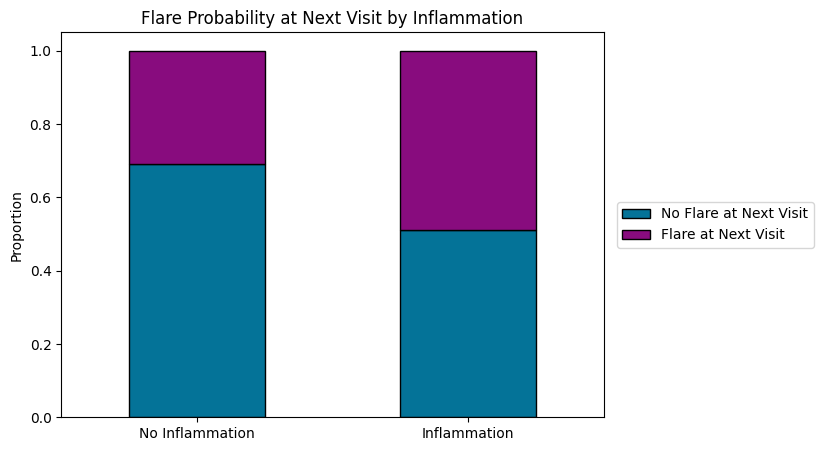

In [184]:
infl_flag.index = infl_flag.index = ["No Inflammation", "Inflammation"]
infl_flag.columns = ['No Flare at Next Visit', 'Flare at Next Visit']
infl_flag.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Inflammation')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()


In [128]:
pd.crosstab(
    df_eda['treatment_decision'],
    df_eda['target_flare_next'],
    rownames=['Treatment Decision'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Treatment Decision,,
escalation,0.52,0.48
no_decision,0.64,0.36
stable,0.63,0.37
switch,0.72,0.28
tapering,0.56,0.44


In [133]:
df_eda['days_since_last_visit_bin'] = pd.cut(
    df_eda['days_since_last_visit'],
    bins=[0, 30, 90, 180, 365, 1000],
    include_lowest=True
)

pd.crosstab(
    df_eda['days_since_last_visit_bin'],
    df_eda['target_flare_next'],
    rownames=['Days Since Last Visit'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Days Since Last Visit,,
"(-0.001, 30.0]",0.65,0.35
"(30.0, 90.0]",0.60,0.40
"(90.0, 180.0]",0.50,0.50
"(180.0, 365.0]",0.61,0.39
"(365.0, 1000.0]",0.62,0.38


In [131]:
df_eda['days_since_last_visit_bin'].value_counts(dropna=True, sort=False)

days_since_last_visit_bin
(0, 30]         8
(30, 90]       35
(90, 180]      44
(180, 365]     41
(365, 1000]    29
Name: count, dtype: int64

In [145]:
df_eda['baseline_visit'] = (df_eda['visit_type'] == 'Baseline').astype(int)
pd.crosstab(
    df_eda['baseline_visit'],
    df_eda['target_flare_next'],
    rownames=['Baseline Visit'],
    colnames=['Flare at Next Visit'],
    normalize='index'
)

Flare at Next Visit,0,1
Baseline Visit,,
0,0.588608,0.411392
1,0.642857,0.357143


In [135]:
df_eda.loc[df_eda['treatment_decision'] == 'Switch', 'switch_reason'].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

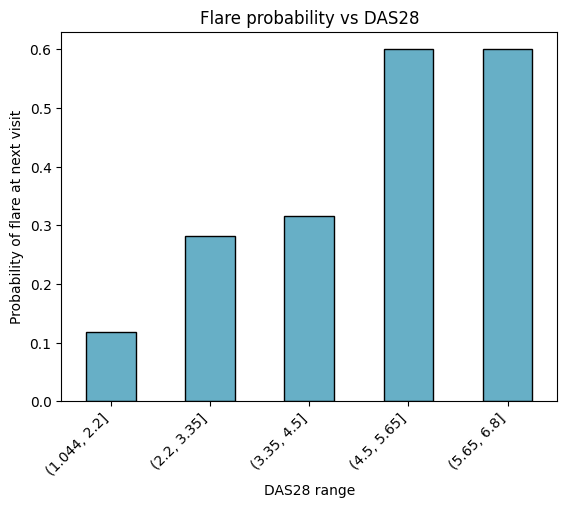

In [141]:
from turtle import color


df_eda['das28_bin'] = pd.cut(df_eda['das28_score'], bins=5)
flare_rate = df_eda.groupby('das28_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#67AFC6FF", edgecolor='black')

plt.title("Flare probability vs DAS28")
plt.ylabel("Probability of flare at next visit")
plt.xlabel("DAS28 range")
plt.xticks(rotation=45, ha='right')
plt.show()


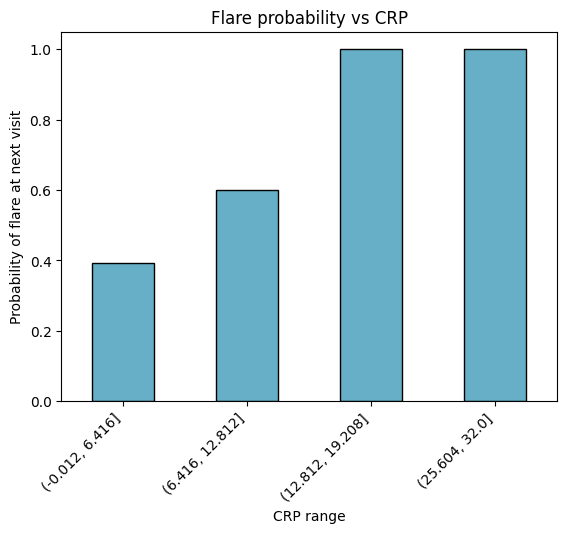

In [142]:
df_eda['crp_bin'] = pd.cut(df_eda['crp_normalized'], bins=5)
flare_rate = df_eda.groupby('crp_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#67AFC6FF", edgecolor='black')

plt.title("Flare probability vs CRP")
plt.ylabel("Probability of flare at next visit")
plt.xlabel("CRP range")
plt.xticks(rotation=45, ha='right')
plt.show()

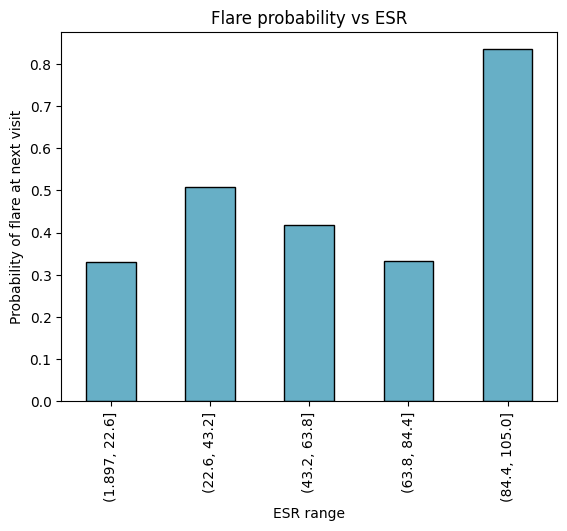

In [143]:
df_eda['esr_bin'] = pd.cut(df_eda['esr'], bins=5)
flare_rate = df_eda.groupby('esr_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#67AFC6FF", edgecolor='black')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("ESR range")
plt.title("Flare probability vs ESR")
plt.show()

### Correlation matrix

<Axes: >

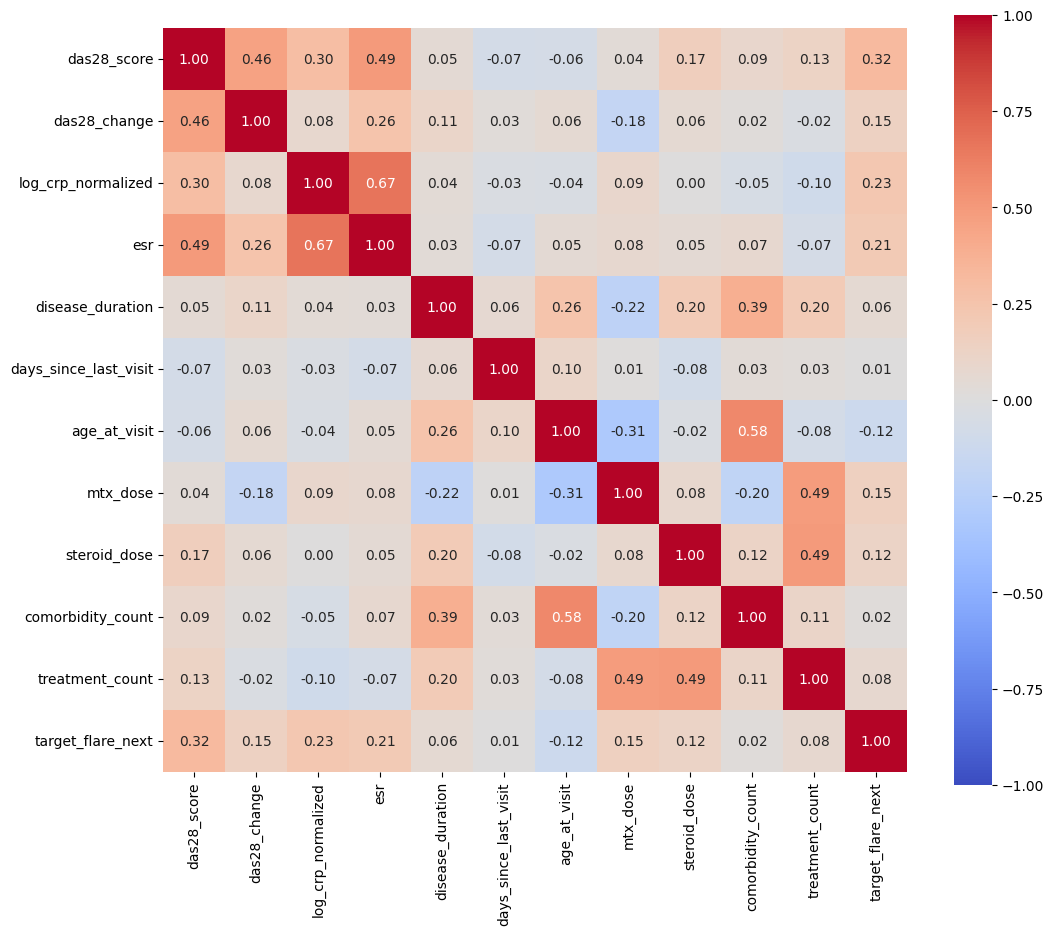

In [186]:
correlation_columns = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'esr', 
    'disease_duration', 'days_since_last_visit',
    'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count',
    'target_flare_next'
]

corr_matrix = df_eda[correlation_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    vmin=-1, vmax=1, center=0,
    cmap='coolwarm', annot=True, fmt=".2f",
    square=True
)

